<a href="https://colab.research.google.com/github/dhruvjoshi0905/Hack-O-Week/blob/main/hack_o_week(12).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install cryptography pandas

In [4]:
import json
import time
import random
import pandas as pd
from datetime import datetime
from cryptography.fernet import Fernet

# ==========================================
# 1. KEY MANAGEMENT (The Zero-Knowledge Rule)
# ==========================================
# In E2E, the database NEVER gets this key. It only lives on the smartwatch and the doctor's dashboard.
e2e_secret_key = Fernet.generate_key()
cipher = Fernet(e2e_secret_key)

# Our simulated Cloud Database (Managed by Affan & Aaditi)
cloud_database = []

In [5]:
# ==========================================
# 2. THE WEARABLE DEVICE (Client-Side Encryption)
# ==========================================
def generate_and_encrypt_payload(device_id="watch_X"):
    """
    Simulates the watch generating JSON data and encrypting it locally.
    """
    # 1. Generate Raw JSON Data
    raw_telemetry = {
        "device_id": device_id,
        "timestamp": datetime.now().isoformat(),
        "heart_rate_bpm": random.randint(65, 115),
        "blood_oxygen_spo2": random.randint(95, 100)
    }

    # 2. Serialize to string, then encode to bytes
    json_string = json.dumps(raw_telemetry)
    byte_payload = json_string.encode('utf-8')

    # 3. Encrypt the payload ON THE DEVICE
    encrypted_payload = cipher.encrypt(byte_payload)

    print(f"[Smartwatch] Generated Data: {json_string}")
    print(f"[Smartwatch] Scrambled Ciphertext: {encrypted_payload[:40]}...\n")

    return encrypted_payload

In [6]:
# ==========================================
# 3. THE BACKEND SERVER (Cloud Storage)
# ==========================================
def backend_store_data(ciphertext):
    """
    The server acts purely as a storage locker. It cannot read the payload.
    """
    record = {
        "record_id": len(cloud_database) + 1,
        "secure_payload": ciphertext,
        "stored_at": datetime.now().strftime("%H:%M:%S")
    }
    cloud_database.append(record)
    print(f"[Backend Cloud] Safely stored encrypted record #{record['record_id']}.\n")

In [7]:
# ==========================================
# 4. THE AUTHORIZED DASHBOARD (Client-Side Decryption)
# ==========================================
def fetch_and_decrypt_dashboard(record_id):
    """
    The dashboard downloads the scrambled data and unlocks it using the secret key.
    """
    # Fetch the ciphertext from the database
    record = next((item for item in cloud_database if item["record_id"] == record_id), None)

    if record:
        try:
            # Decrypt the payload back to bytes
            decrypted_bytes = cipher.decrypt(record["secure_payload"])

            # Convert back to a usable JSON dictionary
            decrypted_json = json.loads(decrypted_bytes.decode('utf-8'))

            print(f"[Doctor Dashboard] Decrypted Record #{record_id} Successfully:")
            print(json.dumps(decrypted_json, indent=2))
        except Exception as e:
            print(f"[Dashboard] Decryption failed. Error: {e}")

In [8]:
# ==========================================
# 5. EXECUTE THE SIMULATION
# ==========================================
print("--- Phase 1: Live Data Ingestion & Encryption ---")
# Generate 3 bursts of wearable data
for _ in range(3):
    secure_packet = generate_and_encrypt_payload()
    backend_store_data(secure_packet)
    time.sleep(0.5)

print("\n--- Phase 2: Database Audit (Proving Zero-Knowledge) ---")
# Show the faculty exactly what the database looks like.
# It proves that even if the database is hacked, no health data is exposed.
db_dataframe = pd.DataFrame(cloud_database)
print("If a hacker breaches the database, this is all they see:")
print(db_dataframe[['record_id', 'secure_payload']])

print("\n--- Phase 3: Authorized Access ---")
# Simulate an authorized user viewing the second record
fetch_and_decrypt_dashboard(record_id=2)

--- Phase 1: Live Data Ingestion & Encryption ---
[Smartwatch] Generated Data: {"device_id": "watch_X", "timestamp": "2026-04-09T05:48:08.822487", "heart_rate_bpm": 87, "blood_oxygen_spo2": 100}
[Smartwatch] Scrambled Ciphertext: b'gAAAAABp1z2Y9b2vPpUhozfeXtCKyNAw9oATKI2L'...

[Backend Cloud] Safely stored encrypted record #1.

[Smartwatch] Generated Data: {"device_id": "watch_X", "timestamp": "2026-04-09T05:48:09.329423", "heart_rate_bpm": 74, "blood_oxygen_spo2": 95}
[Smartwatch] Scrambled Ciphertext: b'gAAAAABp1z2ZoS9TdmMfOAJ_Il7tj_i-UYbhpO5g'...

[Backend Cloud] Safely stored encrypted record #2.

[Smartwatch] Generated Data: {"device_id": "watch_X", "timestamp": "2026-04-09T05:48:09.830925", "heart_rate_bpm": 90, "blood_oxygen_spo2": 97}
[Smartwatch] Scrambled Ciphertext: b'gAAAAABp1z2Zd0US2kIoLO3JlpN7FepGM4pbKsri'...

[Backend Cloud] Safely stored encrypted record #3.


--- Phase 2: Database Audit (Proving Zero-Knowledge) ---
If a hacker breaches the database, this is all they se

### Visualizing the Decrypted Health Data

Now, let's decrypt all the records from the `cloud_database` and visualize the `heart_rate_bpm` and `blood_oxygen_spo2` over time to see the simulated health trends.

In [11]:
import json
import time
import random
import pandas as pd
from datetime import datetime
from cryptography.fernet import Fernet
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. KEY MANAGEMENT (Re-initializing if state lost)
# ==========================================
e2e_secret_key = Fernet.generate_key()
cipher = Fernet(e2e_secret_key)
cloud_database = [] # Re-initialize as it was lost

# ==========================================
# 2. THE WEARABLE DEVICE (Client-Side Encryption) - Re-defining function
# ==========================================
def generate_and_encrypt_payload(device_id="watch_X"):
    """
    Simulates the watch generating JSON data and encrypting it locally.
    """
    raw_telemetry = {
        "device_id": device_id,
        "timestamp": datetime.now().isoformat(),
        "heart_rate_bpm": random.randint(65, 115),
        "blood_oxygen_spo2": random.randint(95, 100)
    }
    json_string = json.dumps(raw_telemetry)
    byte_payload = json_string.encode('utf-8')
    encrypted_payload = cipher.encrypt(byte_payload)
    # print(f"[Smartwatch] Generated Data: {json_string}") # Suppress output for conciseness
    # print(f"[Smartwatch] Scrambled Ciphertext: {encrypted_payload[:40]}...\n") # Suppress output
    return encrypted_payload

# ==========================================
# 3. THE BACKEND SERVER (Cloud Storage) - Re-defining function
# ==========================================
def backend_store_data(ciphertext):
    """
    The server acts purely as a storage locker. It cannot read the payload.
    """
    record = {
        "record_id": len(cloud_database) + 1,
        "secure_payload": ciphertext,
        "stored_at": datetime.now().strftime("%H:%M:%S")
    }
    cloud_database.append(record)
    # print(f"[Backend Cloud] Safely stored encrypted record #{record['record_id']}.\n") # Suppress output

# ==========================================
# 5. EXECUTE THE SIMULATION (Re-running to populate cloud_database)
# ==========================================
print("--- Re-running Simulation to Populate Data ---")
for _ in range(3):
    secure_packet = generate_and_encrypt_payload()
    backend_store_data(secure_packet)
    time.sleep(0.1) # Shorter sleep for quick re-run

# List to store all decrypted data
all_decrypted_data = []

# Iterate through the cloud_database to decrypt all records
for record in cloud_database:
    try:
        decrypted_bytes = cipher.decrypt(record["secure_payload"])
        decrypted_json = json.loads(decrypted_bytes.decode('utf-8'))
        all_decrypted_data.append(decrypted_json)
    except Exception as e:
        print(f"Decryption failed for record {record['record_id']}. Error: {e}")

# Convert the list of dictionaries to a Pandas DataFrame
health_df = pd.DataFrame(all_decrypted_data)

# Convert timestamp to datetime objects for plotting
health_df['timestamp'] = pd.to_datetime(health_df['timestamp'])

# Display the DataFrame to see the collected data
print("\n--- All Decrypted Health Data ---")
display(health_df)


--- Re-running Simulation to Populate Data ---

--- All Decrypted Health Data ---


,device_id,timestamp,heart_rate_bpm,blood_oxygen_spo2
0,watch_X,2026-04-09 05:49:09.166819,70,98
1,watch_X,2026-04-09 05:49:09.267198,99,98
2,watch_X,2026-04-09 05:49:09.367746,66,100


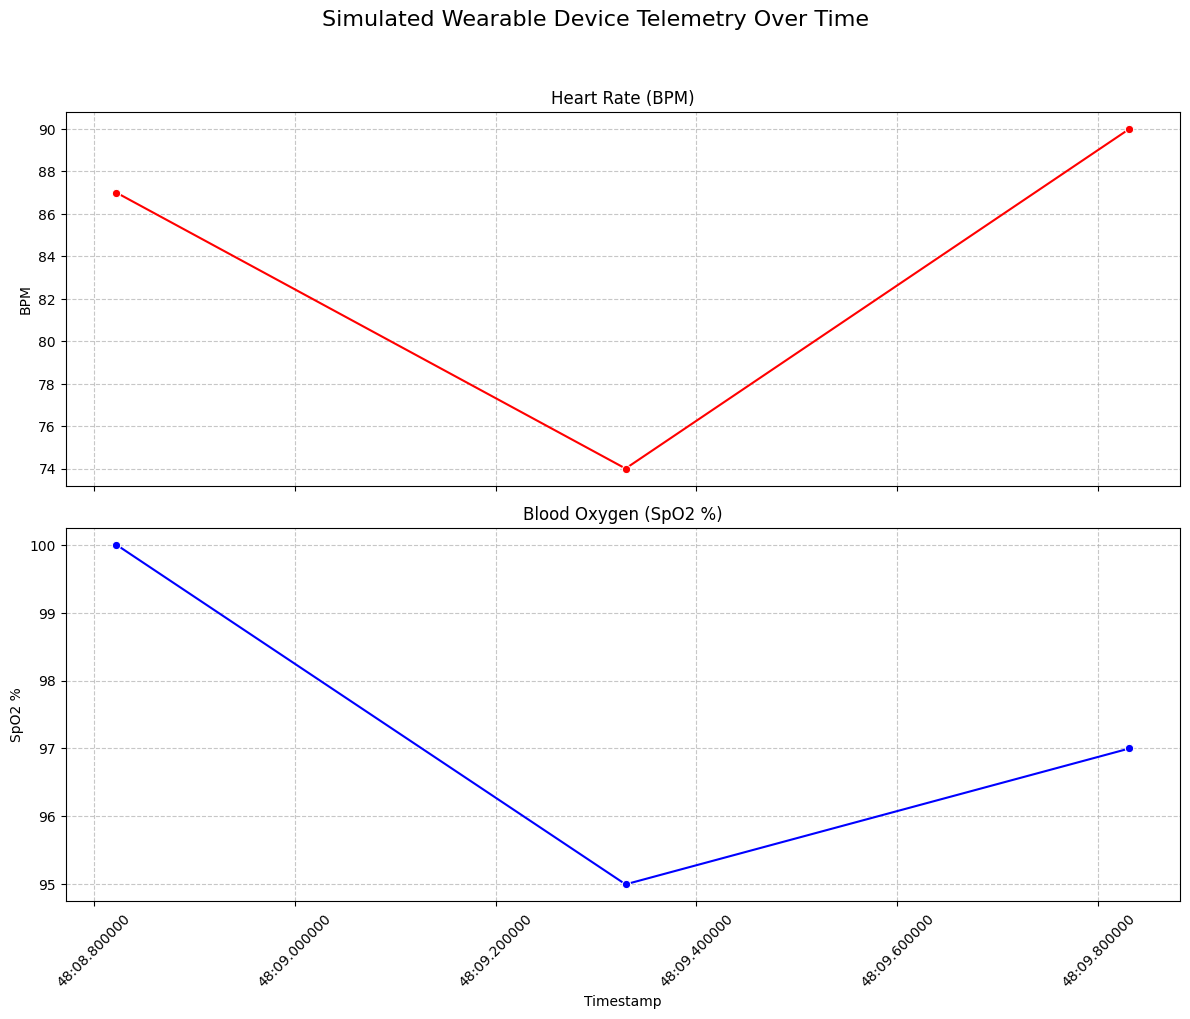

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Simulated Wearable Device Telemetry Over Time', fontsize=16)

# Plot Heart Rate
sns.lineplot(ax=axes[0], x='timestamp', y='heart_rate_bpm', data=health_df, marker='o', color='red')
axes[0].set_title('Heart Rate (BPM)')
axes[0].set_ylabel('BPM')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot Blood Oxygen
sns.lineplot(ax=axes[1], x='timestamp', y='blood_oxygen_spo2', data=health_df, marker='o', color='blue')
axes[1].set_title('Blood Oxygen (SpO2 %)')
axes[1].set_ylabel('SpO2 %')
axes[1].set_xlabel('Timestamp')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.xticks(rotation=45)
plt.show()


### Identifying Potentially Risky Data Points

Let's add some logic to identify data points that could be considered 'risky' based on heart rate and blood oxygen levels. For this simulation:

*   **Elevated Heart Rate:**  `heart_rate_bpm` > 100
*   **Low Blood Oxygen:** `blood_oxygen_spo2` <= 95

We will create new boolean columns in the `health_df` to flag these conditions.

In [12]:
# Define 'risky' thresholds for the simulated data
# Note: These thresholds are for demonstration purposes with the generated data.
# Real medical thresholds may vary.
ELEVATED_HEART_RATE_THRESHOLD = 100
LOW_BLOOD_OXYGEN_THRESHOLD = 95

# Create new columns to flag risky conditions
health_df['is_elevated_heart_rate'] = health_df['heart_rate_bpm'] > ELEVATED_HEART_RATE_THRESHOLD
health_df['is_low_blood_oxygen'] = health_df['blood_oxygen_spo2'] <= LOW_BLOOD_OXYGEN_THRESHOLD

print("\n--- Health Data with Risky Flags ---")
display(health_df)

# Display only the risky records
risky_records = health_df[(health_df['is_elevated_heart_rate']) | (health_df['is_low_blood_oxygen'])]

if not risky_records.empty:
    print("\n--- Potentially Risky Records Identified ---")
    display(risky_records)
else:
    print("\n--- No Potentially Risky Records Identified in this batch. ---")



--- Health Data with Risky Flags ---


,device_id,timestamp,heart_rate_bpm,blood_oxygen_spo2,is_elevated_heart_rate,is_low_blood_oxygen
0,watch_X,2026-04-09 05:49:09.166819,70,98,False,False
1,watch_X,2026-04-09 05:49:09.267198,99,98,False,False
2,watch_X,2026-04-09 05:49:09.367746,66,100,False,False



--- No Potentially Risky Records Identified in this batch. ---
